In [1]:
import numpy as np
import matplotlib.pyplot as plt
from lib_loader import load_my_lib

seed = 42

def plot_classification_zones(mlp, X, resolution=100):
    # Create a grid of points
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                         np.linspace(y_min, y_max, resolution))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Predict on the grid
    predictions_ptr = my_lib.predict_MyMLP(mlp, grid.flatten(), len(grid), grid.shape[1], True)
    predictions = np.ctypeslib.as_array(predictions_ptr, shape=(len(grid), 1))
    predictions = predictions.reshape(xx.shape)

    # Plot the decision boundary
    plt.contourf(xx, yy, predictions, alpha=0.3, levels=[-1, 0, 1], colors=['blue', 'red'])
    plt.scatter(X[:, 0], X[:, 1], c=['blue' if y == 1 else 'red' for y in Y])
    plt.show()

# Chargement de la librairie

In [2]:
path = "../my_lib/target/release/deps/libmy_lib.so"

my_lib = load_my_lib(path)

# XOR

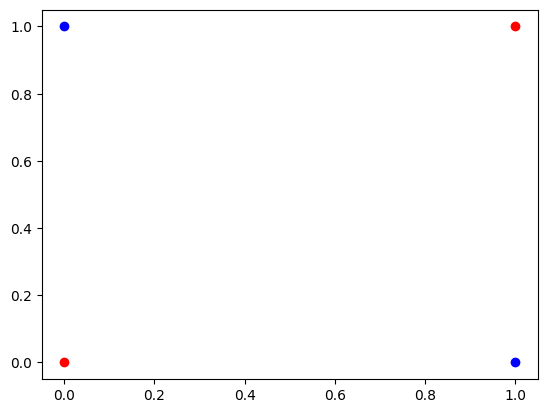

<Figure size 640x480 with 0 Axes>

In [20]:
X = np.array([[1, 0], 
              [0, 1], 
              [0, 0], 
              [1, 1]], dtype=np.float64)
Y = np.array([1, 1, -1, -1], dtype=np.float64)

plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')
plt.show()
plt.clf()

## Linear Model

In [41]:
n_features = 2
n_classes = 1
seed = 0

model = my_lib.create_MyLinearModel(n_features, n_classes, seed)

X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]], dtype=np.float64)
Y = np.array([[1], [1], [-1], [-1]], dtype=np.float64)

# Entraîner le modèle
learning_rate = 0.1
epochs = 1000
is_classification = 1

my_lib.train_MyLinearModel(
    model,
    X,
    Y,
    X,
    Y,
    X.shape[0],
    X.shape[0],
    n_features,
    n_classes,
    learning_rate,
    epochs,
    is_classification
)

predictions_ptr = my_lib.predict_MyLinearModel(model, X, X.shape[0], n_features, is_classification)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(X.shape[0], n_classes))

Training starting...
Epoch 0: Train Loss: 1.7427, Test Loss: 1.4315, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 1: Train Loss: 1.5363, Test Loss: 1.2303, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 2: Train Loss: 1.3882, Test Loss: 1.1301, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 3: Train Loss: 1.3189, Test Loss: 1.0873, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 4: Train Loss: 1.2878, Test Loss: 1.0674, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 5: Train Loss: 1.2714, Test Loss: 1.0566, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 6: Train Loss: 1.2615, Test Loss: 1.0500, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 7: Train Loss: 1.2548, Test Loss: 1.0456, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 8: Train Loss: 1.2501, Test Loss: 1.0424, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 9: Train Loss: 1.2465, Test Loss: 1.0400, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 10: Train Loss: 1.2438, Test Loss: 1.0382, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 11: Train Loss: 1.2416, Test Loss: 1.0367, Train

In [42]:
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(X.shape[0], n_classes))
predictions

array([[-0.11060624],
       [-0.21853893],
       [-0.11060624],
       [-0.21853893]])

## RBF

In [21]:
n_centers = 4  # Vous pouvez ajuster ce nombre selon vos besoins
input_dim = 2
output_dim = 1
gamma = 0.1
seed = 0

centers = X.astype(np.float64)
model = my_lib.create_MyRBF(centers, n_centers, input_dim, output_dim, gamma, seed)

# Entraîner le modèle
learning_rate = 0.001
epochs = 1000
is_classification = True

my_lib.train_MyRBF(
    model,
    X,
    Y,
    X,
    Y,
    X.shape[0],
    X.shape[0],
    input_dim,
    output_dim,
    learning_rate,
    epochs,
    is_classification
)

LOOOL
Training starting...
Epoch 0: Train Loss: 2.0000, Test Loss: 2.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 1: Train Loss: 2.0000, Test Loss: 2.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 2: Train Loss: 2.0000, Test Loss: 2.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 3: Train Loss: 2.0000, Test Loss: 2.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 4: Train Loss: 2.0000, Test Loss: 2.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 5: Train Loss: 2.0000, Test Loss: 2.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 6: Train Loss: 2.0000, Test Loss: 2.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 7: Train Loss: 2.0000, Test Loss: 2.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 8: Train Loss: 2.0000, Test Loss: 2.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 9: Train Loss: 2.0000, Test Loss: 2.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 10: Train Loss: 2.0000, Test Loss: 2.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 11: Train Loss: 2.0000, Test Loss: 2.0000,

0

In [22]:
predictions_ptr = my_lib.predict_MyRBF(model, X, X.shape[0], input_dim, is_classification)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(X.shape[0], output_dim))
predictions

array([[ 1.],
       [ 1.],
       [-1.],
       [-1.]])

## MLP

In [16]:
layer_sizes = np.array([2, 3, 1], dtype=np.int32) 
mlp = my_lib.create_MyMLP(layer_sizes, len(layer_sizes), 42)

# Train the MLP model
my_lib.train_MyMLP(
    mlp,
    X.flatten(),
    Y.reshape(-1,1).flatten(),
    X.flatten(),  # Using the same data for testing for simplicity
    Y.reshape(-1,1).flatten(),
    len(X),
    len(X),
    X.shape[1],
    Y.reshape(-1,1).shape[1],
    0.1,  
    1000,  
    True 
)

predictions_ptr = my_lib.predict_MyMLP(mlp, X.flatten(), len(X), X.shape[1], True)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(len(X), 1))
my_lib.destroy_MyMLP(mlp)

Training starting...
Epoch 0: Train Loss: 1.4990, Test Loss: 1.3168, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 1: Train Loss: 1.4404, Test Loss: 1.2563, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 2: Train Loss: 1.3988, Test Loss: 1.2200, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 3: Train Loss: 1.3709, Test Loss: 1.1966, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 4: Train Loss: 1.3513, Test Loss: 1.1796, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 5: Train Loss: 1.3361, Test Loss: 1.1654, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 6: Train Loss: 1.3229, Test Loss: 1.1524, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 7: Train Loss: 1.3107, Test Loss: 1.1398, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 8: Train Loss: 1.2989, Test Loss: 1.1273, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 9: Train Loss: 1.2873, Test Loss: 1.1149, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 10: Train Loss: 1.2759, Test Loss: 1.1027, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 11: Train Loss: 1.2648, Test Loss: 1.0908, Train

0

In [17]:
print("Predictions:\n", predictions)

Predictions:
 [[ 0.95761499]
 [ 0.96426027]
 [-0.97324543]
 [-0.95532422]]


# Linear Simple

In [23]:
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
], dtype=np.float64)


y = np.array([
      1,
      -1,
      -1
], dtype=np.float64)

## Linear Model

In [47]:
n_features = 2
n_classes = 1
seed = 0

model = my_lib.create_MyLinearModel(n_features, n_classes, seed)

Y = y.reshape(-1, 1)

learning_rate = 0.1
epochs = 1000
is_classification = 1

my_lib.train_MyLinearModel(
    model,
    X,
    Y,
    X,
    Y,
    X.shape[0],
    X.shape[0],
    n_features,
    n_classes,
    learning_rate,
    epochs,
    is_classification
)

Training starting...
Epoch 0: Train Loss: 1.1829, Test Loss: 0.7155, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 1: Train Loss: 0.7707, Test Loss: 0.6377, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 2: Train Loss: 0.6997, Test Loss: 0.5934, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 3: Train Loss: 0.6498, Test Loss: 0.5518, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 4: Train Loss: 0.6027, Test Loss: 0.5123, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 5: Train Loss: 0.5582, Test Loss: 0.4750, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 6: Train Loss: 0.5163, Test Loss: 0.4400, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 7: Train Loss: 0.4772, Test Loss: 0.4074, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 8: Train Loss: 0.4409, Test Loss: 0.3771, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 9: Train Loss: 0.4073, Test Loss: 0.3492, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 10: Train Loss: 0.3764, Test Loss: 0.3234, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 11: Train Loss: 0.3481, Test Loss: 0.2998, Train

0

In [48]:
predictions_ptr = my_lib.predict_MyLinearModel(model, X, X.shape[0], n_features, is_classification)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(X.shape[0], n_classes))
predictions

array([[ 0.98243657],
       [-0.99581022],
       [-0.99689554]])

## RBF

In [24]:
n_centers = 3
input_dim = 2
output_dim = 1
gamma = 0.1
seed = 0

centers = X.astype(np.float64)
model = my_lib.create_MyRBF(centers, n_centers, input_dim, output_dim, gamma, seed)

learning_rate = 0.01
epochs = 1000
is_classification = True

my_lib.train_MyRBF(
    model,
    X,
    y,
    X,
    y,
    X.shape[0],
    X.shape[0],
    input_dim,
    output_dim,
    learning_rate,
    epochs,
    is_classification
)

LOOOL
Training starting...
Epoch 0: Train Loss: 4.0000, Test Loss: 4.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 1: Train Loss: 4.0000, Test Loss: 4.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 2: Train Loss: 4.0000, Test Loss: 4.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 3: Train Loss: 4.0000, Test Loss: 4.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 4: Train Loss: 4.0000, Test Loss: 4.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 5: Train Loss: 4.0000, Test Loss: 4.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 6: Train Loss: 4.0000, Test Loss: 4.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 7: Train Loss: 4.0000, Test Loss: 4.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 8: Train Loss: 4.0000, Test Loss: 4.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 9: Train Loss: 4.0000, Test Loss: 4.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 10: Train Loss: 4.0000, Test Loss: 4.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 11: Train Loss: 4.0000, Test Loss: 4.0000,

0

In [25]:
predictions_ptr = my_lib.predict_MyRBF(model, X, X.shape[0], input_dim, is_classification)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(X.shape[0], output_dim))
predictions

array([[ 1.],
       [-1.],
       [-1.]])

## MLP

In [39]:
layer_sizes = np.array([2, 1], dtype=np.int32) 
mlp = my_lib.create_MyMLP(layer_sizes, len(layer_sizes), 42)

my_lib.train_MyMLP(
    mlp,
    X.flatten(),
    Y.reshape(-1,1).flatten(),
    X.flatten(),
    Y.reshape(-1,1).flatten(),
    len(X),
    len(X),
    X.shape[1],
    Y.reshape(-1,1).shape[1],
    0.01,  
    1000,  
    True 
)

predictions_ptr = my_lib.predict_MyMLP(mlp, X.flatten(), len(X), X.shape[1], True)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(len(X), 1))
my_lib.destroy_MyMLP(mlp)

Training starting...
Epoch 0: Train Loss: 1.2508, Test Loss: 1.2168, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 1: Train Loss: 1.2376, Test Loss: 1.1976, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 2: Train Loss: 1.2222, Test Loss: 1.1748, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 3: Train Loss: 1.2041, Test Loss: 1.1479, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 4: Train Loss: 1.1833, Test Loss: 1.1169, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 5: Train Loss: 1.1597, Test Loss: 1.0821, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 6: Train Loss: 1.1340, Test Loss: 1.0449, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 7: Train Loss: 1.1073, Test Loss: 1.0077, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 8: Train Loss: 1.0814, Test Loss: 0.9735, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 9: Train Loss: 1.0581, Test Loss: 0.9450, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 10: Train Loss: 1.0389, Test Loss: 0.9234, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 11: Train Loss: 1.0242, Test Loss: 0.9084, Train

0

In [44]:
print("Predictions:\n", predictions)

Predictions:
 [[ 0.78754065]
 [ 0.76517857]
 [-0.75589243]]


# Linear Simple 2

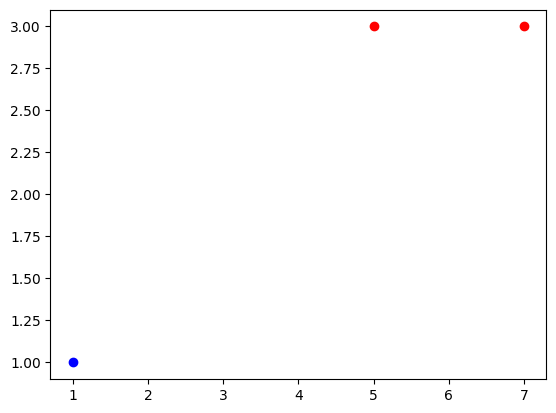

<Figure size 640x480 with 0 Axes>

In [26]:
X = np.array([
      [1, 1],
      [5, 3],
      [7, 3]
], dtype=np.float64)
Y = np.array([
      1,
      -1,
      -1
], dtype=np.float64)

plt.scatter(X[0, 0], X[0, 1], color='blue')
plt.scatter(X[1:3,0], X[1:3,1], color='red')
plt.show()
plt.clf()

## Linear Model

In [52]:
Y = Y.reshape(-1, 1)

learning_rate = 0.01
epochs = 1000
is_classification = 1

my_lib.train_MyLinearModel(
    model,
    X,
    Y,
    X,
    Y,
    X.shape[0],
    X.shape[0],
    n_features,
    n_classes,
    learning_rate,
    epochs,
    is_classification
)

Training starting...
Epoch 0: Train Loss: 0.0001, Test Loss: 0.0001, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 1: Train Loss: 0.0001, Test Loss: 0.0001, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 2: Train Loss: 0.0001, Test Loss: 0.0001, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 3: Train Loss: 0.0001, Test Loss: 0.0001, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 4: Train Loss: 0.0001, Test Loss: 0.0001, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 5: Train Loss: 0.0001, Test Loss: 0.0001, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 6: Train Loss: 0.0001, Test Loss: 0.0001, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 7: Train Loss: 0.0001, Test Loss: 0.0001, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 8: Train Loss: 0.0001, Test Loss: 0.0001, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 9: Train Loss: 0.0001, Test Loss: 0.0001, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 10: Train Loss: 0.0001, Test Loss: 0.0001, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 11: Train Loss: 0.0001, Test Loss: 0.0001, Train

0

In [54]:
predictions_ptr = my_lib.predict_MyLinearModel(model, X, X.shape[0], n_features, is_classification)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(X.shape[0], n_classes))
predictions

array([[ 0.98668039],
       [-0.99783976],
       [-0.99895712]])

## RBF

In [27]:
n_centers = 3
input_dim = 2
output_dim = 1
gamma = 0.1
seed = 0

centers = X.astype(np.float64)
model = my_lib.create_MyRBF(centers, n_centers, input_dim, output_dim, gamma, seed)

learning_rate = 0.01
epochs = 1000
is_classification = True

my_lib.train_MyRBF(
    model,
    X,
    Y,
    X,
    Y,
    X.shape[0],
    X.shape[0],
    input_dim,
    output_dim,
    learning_rate,
    epochs,
    is_classification
)

LOOOL
Training starting...
Epoch 0: Train Loss: 2.6667, Test Loss: 2.6667, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 1: Train Loss: 2.6667, Test Loss: 2.6667, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 2: Train Loss: 2.6667, Test Loss: 2.6667, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 3: Train Loss: 2.6667, Test Loss: 2.6667, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 4: Train Loss: 2.6667, Test Loss: 2.6667, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 5: Train Loss: 2.6667, Test Loss: 1.3333, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 6: Train Loss: 1.3333, Test Loss: 1.3333, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 7: Train Loss: 1.3333, Test Loss: 1.3333, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 8: Train Loss: 1.3333, Test Loss: 1.3333, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 9: Train Loss: 1.3333, Test Loss: 1.3333, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 10: Train Loss: 1.3333, Test Loss: 1.3333, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 11: Train Loss: 1.3333, Test Loss: 0.0000,

0

In [28]:
predictions_ptr = my_lib.predict_MyRBF(model, X, X.shape[0], input_dim, is_classification)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(X.shape[0], output_dim))
predictions

array([[ 1.],
       [-1.],
       [-1.]])

## MLP

In [48]:
layer_sizes = np.array([2, 1], dtype=np.int32) 
mlp = my_lib.create_MyMLP(layer_sizes, len(layer_sizes), 42)

my_lib.train_MyMLP(
    mlp,
    X.flatten(),
    Y.reshape(-1,1).flatten(),
    X.flatten(),  # Using the same data for testing for simplicity
    Y.reshape(-1,1).flatten(),
    len(X),
    len(X),
    X.shape[1],
    Y.reshape(-1,1).shape[1],
    0.01,  
    1000,  
    True 
)

predictions_ptr = my_lib.predict_MyMLP(mlp, X.flatten(), len(X), X.shape[1], True)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(len(X), 1))
my_lib.destroy_MyMLP(mlp)

Training starting...
Epoch 0: Train Loss: 2.4572, Test Loss: 2.2390, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 1: Train Loss: 2.1308, Test Loss: 1.3585, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 2: Train Loss: 1.1148, Test Loss: 0.5393, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 3: Train Loss: 0.5475, Test Loss: 0.4587, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 4: Train Loss: 0.4781, Test Loss: 0.4410, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 5: Train Loss: 0.4589, Test Loss: 0.4329, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 6: Train Loss: 0.4493, Test Loss: 0.4270, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 7: Train Loss: 0.4423, Test Loss: 0.4217, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 8: Train Loss: 0.4362, Test Loss: 0.4165, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 9: Train Loss: 0.4305, Test Loss: 0.4114, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 10: Train Loss: 0.4250, Test Loss: 0.4063, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 11: Train Loss: 0.4196, Test Loss: 0.4012, Train

0

In [49]:
predictions

array([[ 0.82497063],
       [-0.91174261],
       [-0.99797042]])

# Linear Multiple

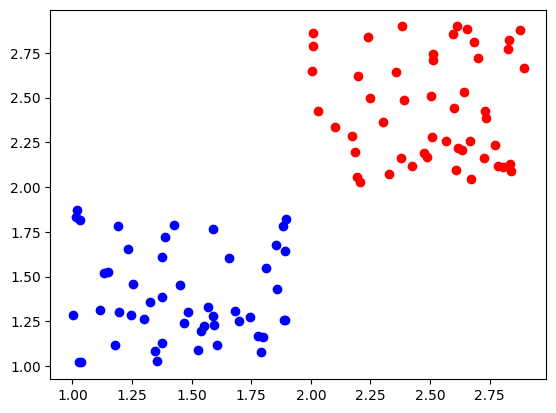

<Figure size 640x480 with 0 Axes>

In [29]:
X = np.concatenate([np.random.random((50, 2)) * 0.9 + np.array([1, 1]), np.random.random((50, 2)) * 0.9 + np.array([2, 2])]).astype(np.float64)
Y = np.concatenate([np.ones((50, 1)), np.ones((50, 1)) * -1.0]).astype(np.float64)

# Plot the original data
plt.scatter(X[0:50, 0], X[0:50, 1], color='blue')
plt.scatter(X[50:100, 0], X[50:100, 1], color='red')
plt.show()
plt.clf()

## Linear Model

In [56]:
n_features = 2
n_classes = 1
seed = 0

model = my_lib.create_MyLinearModel(n_features, n_classes, seed)

X = np.concatenate([np.random.random((50, 2)) * 0.9 + np.array([1, 1]), np.random.random((50, 2)) * 0.9 + np.array([2, 2])]).astype(np.float64)
Y = np.concatenate([np.ones((50, 1)), np.ones((50, 1)) * -1.0]).astype(np.float64)

learning_rate = 0.01
epochs = 1000
is_classification = 1

my_lib.train_MyLinearModel(
    model,
    X,
    Y,
    X,
    Y,
    X.shape[0],
    X.shape[0],
    n_features,
    n_classes,
    learning_rate,
    epochs,
    is_classification
)

Training starting...
Epoch 0: Train Loss: 0.4295, Test Loss: 1.3664, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 1: Train Loss: 0.5060, Test Loss: 1.3686, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 2: Train Loss: 0.4989, Test Loss: 1.3327, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 3: Train Loss: 0.4813, Test Loss: 1.2964, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 4: Train Loss: 0.4644, Test Loss: 1.2601, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 5: Train Loss: 0.4482, Test Loss: 1.2239, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 6: Train Loss: 0.4327, Test Loss: 1.1880, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 7: Train Loss: 0.4179, Test Loss: 1.1524, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 8: Train Loss: 0.4037, Test Loss: 1.1172, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 9: Train Loss: 0.3902, Test Loss: 1.0826, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 10: Train Loss: 0.3772, Test Loss: 1.0487, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 11: Train Loss: 0.3648, Test Loss: 1.0154, Train

0

In [57]:
predictions_ptr = my_lib.predict_MyLinearModel(model, X, X.shape[0], n_features, is_classification)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(X.shape[0], n_classes))
predictions

array([[ 0.41118908],
       [ 0.99944086],
       [ 0.99200586],
       [ 0.99607846],
       [ 0.97034543],
       [ 0.99967451],
       [ 0.99578888],
       [ 0.92893666],
       [ 0.76385224],
       [ 0.9962626 ],
       [ 0.99988061],
       [ 0.99278166],
       [ 0.99992813],
       [ 0.99678507],
       [ 0.9947382 ],
       [ 0.84034317],
       [ 0.99619003],
       [ 0.93284132],
       [ 0.88000678],
       [ 0.98758167],
       [ 0.94500744],
       [ 0.9999446 ],
       [ 0.99844366],
       [ 0.99409808],
       [ 0.99354657],
       [ 0.99520888],
       [ 0.99567276],
       [ 0.76417161],
       [ 0.983196  ],
       [ 0.9973165 ],
       [ 0.87799578],
       [ 0.84490717],
       [ 0.98879717],
       [ 0.86150056],
       [ 0.91867064],
       [ 0.99903584],
       [ 0.98680473],
       [ 0.98867505],
       [ 0.98529246],
       [ 0.83687795],
       [ 0.98852537],
       [ 0.99977015],
       [ 0.96283878],
       [ 0.9812874 ],
       [ 0.99729028],
       [ 0

## RBF

In [30]:
n_centers = 10
input_dim = 2
output_dim = 1
gamma = 0.1
seed = 0

centers = np.concatenate([np.random.random((n_centers // 2, 2)) * 0.9 + np.array([1, 1]), np.random.random((n_centers // 2, 2)) * 0.9 + np.array([2, 2])]).astype(np.float64)
model = my_lib.create_MyRBF(centers, n_centers, input_dim, output_dim, gamma, seed)

learning_rate = 0.01
epochs = 1000
is_classification = True

my_lib.train_MyRBF(
    model,
    X,
    Y,
    X,
    Y,
    X.shape[0],
    X.shape[0],
    input_dim,
    output_dim,
    learning_rate,
    epochs,
    is_classification
)

LOOOL
Training starting...
Epoch 0: Train Loss: 1.8000, Test Loss: 1.5600, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 1: Train Loss: 1.0000, Test Loss: 1.4400, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 2: Train Loss: 0.8400, Test Loss: 1.3600, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 3: Train Loss: 0.7600, Test Loss: 1.2800, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 4: Train Loss: 0.6400, Test Loss: 1.2800, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 5: Train Loss: 0.5600, Test Loss: 1.2800, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 6: Train Loss: 0.4800, Test Loss: 1.2800, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 7: Train Loss: 0.4800, Test Loss: 1.2800, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 8: Train Loss: 0.4000, Test Loss: 1.2800, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 9: Train Loss: 0.4000, Test Loss: 1.2000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 10: Train Loss: 0.4000, Test Loss: 1.2000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 11: Train Loss: 0.3200, Test Loss: 1.2000,

0

In [31]:
predictions_ptr = my_lib.predict_MyRBF(model, X, X.shape[0], input_dim, is_classification)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(X.shape[0], output_dim))
predictions

array([[ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [-1.],
       [ 1.],
       [-1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [-1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [-1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [-1.],
       [ 1.],
       [-1.],
       [ 1.],
       [-1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [-1.],
       [ 1.],
       [ 1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
      

## MLP

In [11]:
layer_sizes = np.array([2, 4, 1], dtype=np.int32)
mlp = my_lib.create_MyMLP(layer_sizes, len(layer_sizes), 42)

# Train the MLP model
my_lib.train_MyMLP(
    mlp,
    X.flatten(),
    Y.flatten(),
    X.flatten(),  # Using the same data for testing for simplicity
    Y.flatten(),
    len(X),
    len(X),
    X.shape[1],
    Y.shape[1],
    0.01,
    1000,
    True
)

predictions_ptr = my_lib.predict_MyMLP(mlp, X.flatten(), len(X), X.shape[1], True)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(len(X), 1))

# Print predictions
print("Predictions:", predictions)

Training starting...
Epoch 0: Train Loss: 0.5639, Test Loss: 1.2354, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 1: Train Loss: 0.4678, Test Loss: 1.2093, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 2: Train Loss: 0.4249, Test Loss: 1.1806, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 3: Train Loss: 0.3854, Test Loss: 1.1479, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 4: Train Loss: 0.3489, Test Loss: 1.1117, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 5: Train Loss: 0.3155, Test Loss: 1.0721, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 6: Train Loss: 0.2852, Test Loss: 1.0298, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 7: Train Loss: 0.2579, Test Loss: 0.9852, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 8: Train Loss: 0.2336, Test Loss: 0.9390, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 9: Train Loss: 0.2119, Test Loss: 0.8919, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 10: Train Loss: 0.1928, Test Loss: 0.8446, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 11: Train Loss: 0.1759, Test Loss: 0.7978, Train

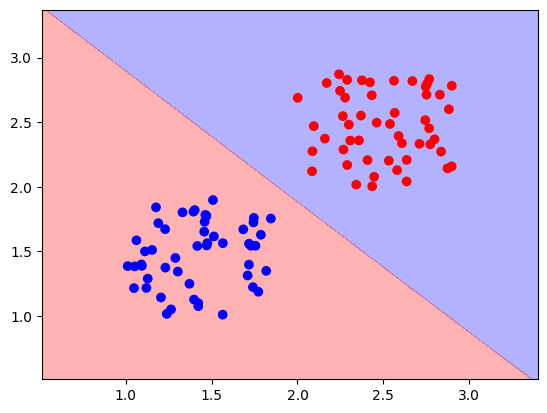

0

In [12]:
plot_classification_zones(mlp,X)

my_lib.destroy_MyMLP(mlp)

# Cross

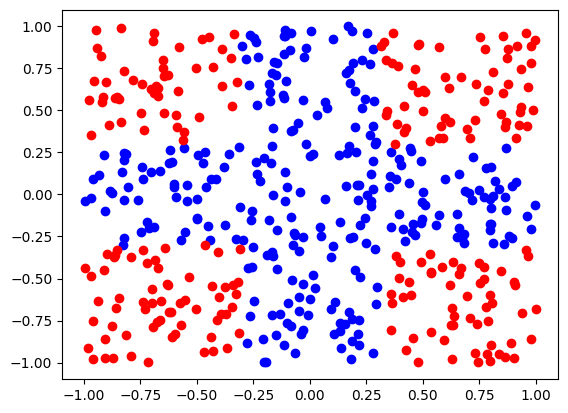

<Figure size 640x480 with 0 Axes>

In [3]:
X = (np.random.random((500, 2)) * 2.0 - 1.0).astype(np.float64)
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X], dtype=np.float64)

# Plot the original data
plt.scatter(np.array(list(map(lambda elt: elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:, 0], 
            np.array(list(map(lambda elt: elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:, 1], 
            color='blue')
plt.scatter(np.array(list(map(lambda elt: elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:, 0], 
            np.array(list(map(lambda elt: elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:, 1], 
            color='red')
plt.show()
plt.clf()

## Linear Model

In [6]:
n_features = 2
n_classes = 1
seed = 0

model = my_lib.create_MyLinearModel(n_features, n_classes, seed)

X = (np.random.random((500, 2)) * 2.0 - 1.0).astype(np.float64)
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X], dtype=np.float64)

Y = Y.reshape(-1, 1)

learning_rate = 0.1
epochs = 1000
is_classification = 1

my_lib.train_MyLinearModel(
    model,
    X,
    Y,
    X,
    Y,
    X.shape[0],
    X.shape[0],
    n_features,
    n_classes,
    learning_rate,
    epochs,
    is_classification
)

Training starting...
Epoch 0: Train Loss: 1.1005, Test Loss: 1.1760, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 1: Train Loss: 1.0855, Test Loss: 1.1760, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 2: Train Loss: 1.0855, Test Loss: 1.1760, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 3: Train Loss: 1.0855, Test Loss: 1.1760, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 4: Train Loss: 1.0855, Test Loss: 1.1760, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 5: Train Loss: 1.0855, Test Loss: 1.1760, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 6: Train Loss: 1.0855, Test Loss: 1.1760, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 7: Train Loss: 1.0855, Test Loss: 1.1760, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 8: Train Loss: 1.0855, Test Loss: 1.1760, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 9: Train Loss: 1.0855, Test Loss: 1.1760, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 10: Train Loss: 1.0855, Test Loss: 1.1760, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 11: Train Loss: 1.0855, Test Loss: 1.1760, Train

0

In [7]:
predictions_ptr = my_lib.predict_MyLinearModel(model, X, X.shape[0], n_features, is_classification)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(X.shape[0], n_classes))
predictions

array([[-0.33044109],
       [-0.49943779],
       [-0.16766496],
       [-0.23578324],
       [-0.44665249],
       [-0.4317625 ],
       [-0.26977894],
       [-0.3789116 ],
       [-0.24789525],
       [-0.23405109],
       [-0.43277318],
       [-0.56104111],
       [-0.27728892],
       [-0.39330571],
       [-0.37051974],
       [-0.48977709],
       [-0.33777064],
       [-0.3662391 ],
       [-0.19573647],
       [-0.18222098],
       [-0.47921826],
       [-0.38601384],
       [-0.45502731],
       [-0.44951412],
       [-0.43812004],
       [-0.34534682],
       [-0.45937361],
       [-0.24056763],
       [-0.4350465 ],
       [-0.18999425],
       [-0.56264874],
       [-0.30034753],
       [-0.33499856],
       [-0.43066252],
       [-0.25596763],
       [-0.3901461 ],
       [-0.56780586],
       [-0.38120035],
       [-0.28475548],
       [-0.48908912],
       [-0.41875819],
       [-0.39578193],
       [-0.53487625],
       [-0.4892897 ],
       [-0.23618477],
       [-0

## RBF

In [32]:
n_centers = 10
input_dim = 2
output_dim = 1
gamma = 0.1
seed = 0

centers = X[np.random.choice(X.shape[0], n_centers, replace=False)].astype(np.float64)
model = my_lib.create_MyRBF(centers, n_centers, input_dim, output_dim, gamma, seed)

learning_rate = 0.01
epochs = 1000
is_classification = True

my_lib.train_MyRBF(
    model,
    X,
    Y,
    X,
    Y,
    X.shape[0],
    X.shape[0],
    input_dim,
    output_dim,
    learning_rate,
    epochs,
    is_classification
)

LOOOL
Training starting...
Epoch 0: Train Loss: 0.5200, Test Loss: 1.4800, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 1: Train Loss: 0.6400, Test Loss: 1.4800, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 2: Train Loss: 0.6400, Test Loss: 1.4800, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 3: Train Loss: 0.6000, Test Loss: 1.5200, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 4: Train Loss: 0.6400, Test Loss: 1.5200, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 5: Train Loss: 0.6400, Test Loss: 1.4800, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 6: Train Loss: 0.6400, Test Loss: 1.3600, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 7: Train Loss: 0.6400, Test Loss: 1.3600, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 8: Train Loss: 0.6400, Test Loss: 1.3200, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 9: Train Loss: 0.5200, Test Loss: 1.2800, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 10: Train Loss: 0.4400, Test Loss: 1.2400, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 11: Train Loss: 0.3600, Test Loss: 1.2000,

0

In [33]:
predictions_ptr = my_lib.predict_MyRBF(model, X, X.shape[0], input_dim, is_classification)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(X.shape[0], output_dim))
predictions

array([[ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [-1.],
       [-1.],
       [ 1.],
       [ 1.],
       [-1.],
       [ 1.],
       [ 1.],
       [-1.],
       [ 1.],
       [-1.],
       [-1.],
       [ 1.],
       [ 1.],
       [-1.],
       [ 1.],
       [-1.],
       [ 1.],
       [-1.],
       [ 1.],
       [-1.],
       [ 1.],
       [-1.],
       [ 1.],
       [-1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [-1.],
       [-1.],
       [ 1.],
       [-1.],
       [-1.],
       [ 1.],
       [ 1.],
       [-1.],
       [ 1.],
       [-1.],
       [-1.],
       [ 1.],
       [ 1.],
       [-1.],
       [ 1.],
       [ 1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
      

## MLP

In [8]:
layer_sizes = np.array([2, 3, 1], dtype=np.int32)
mlp = my_lib.create_MyMLP(layer_sizes, len(layer_sizes), 42)

# Train the MLP model
my_lib.train_MyMLP(
    mlp,
    X.flatten(),
    Y.flatten(),
    X.flatten(),
    Y.flatten(),
    len(X),
    len(X),
    X.shape[1],
    1, 
    0.01,
    1000,
    True 
)

predictions_ptr = my_lib.predict_MyMLP(mlp, X.flatten(), len(X), X.shape[1], True)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(len(X), 1))

Training starting...
Epoch 0: Train Loss: 1.1116, Test Loss: 0.9966, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 1: Train Loss: 0.9880, Test Loss: 0.9846, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 2: Train Loss: 0.9763, Test Loss: 0.9709, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 3: Train Loss: 0.9599, Test Loss: 0.9511, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 4: Train Loss: 0.9364, Test Loss: 0.9236, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 5: Train Loss: 0.9050, Test Loss: 0.8890, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 6: Train Loss: 0.8678, Test Loss: 0.8505, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 7: Train Loss: 0.8296, Test Loss: 0.8140, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 8: Train Loss: 0.7959, Test Loss: 0.7836, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 9: Train Loss: 0.7690, Test Loss: 0.7596, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 10: Train Loss: 0.7482, Test Loss: 0.7408, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 11: Train Loss: 0.7318, Test Loss: 0.7256, Train

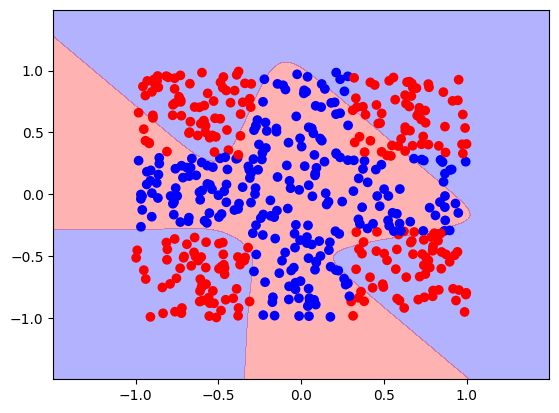

In [9]:
plot_classification_zones(mlp, X)

# Multi Linear 3 classes

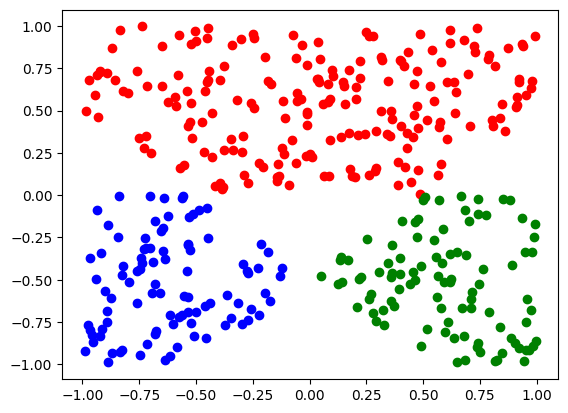

<Figure size 640x480 with 0 Axes>

In [41]:
X = (np.random.random((500, 2)) * 2.0 - 1.0).astype(np.float64)
Y = np.array([[1, 0, 0] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [0, 1, 0] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [0, 0, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [0, 0, 0] for p in X], dtype=np.float64)

X = X[[not np.all(arr == [0, 0, 0]) for arr in Y]]
Y = Y[[not np.all(arr == [0, 0, 0]) for arr in Y]]

# Plot the original data
plt.scatter(np.array(list(map(lambda elt: elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:, 0],
            np.array(list(map(lambda elt: elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:, 1],
            color='blue')
plt.scatter(np.array(list(map(lambda elt: elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:, 0],
            np.array(list(map(lambda elt: elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:, 1],
            color='red')
plt.scatter(np.array(list(map(lambda elt: elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:, 0],
            np.array(list(map(lambda elt: elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:, 1],
            color='green')
plt.show()
plt.clf()

## Linear Model

In [9]:
n_features = 2
n_classes = 3
seed = 0

model = my_lib.create_MyLinearModel(n_features, n_classes, seed)

learning_rate = 0.1
epochs = 1000
is_classification = 1

my_lib.train_MyLinearModel(
    model,
    X,
    Y,
    X,
    Y,
    X.shape[0],
    X.shape[0],
    n_features,
    n_classes,
    learning_rate,
    epochs,
    is_classification
)

Training starting...
Epoch 0: Train Loss: 0.2962, Test Loss: 0.2467, Train Acc: 88.9%, Test Acc: 97.3%
Epoch 1: Train Loss: 0.2540, Test Loss: 0.2485, Train Acc: 92.3%, Test Acc: 97.3%
Epoch 2: Train Loss: 0.2545, Test Loss: 0.2486, Train Acc: 92.3%, Test Acc: 97.3%
Epoch 3: Train Loss: 0.2545, Test Loss: 0.2486, Train Acc: 92.3%, Test Acc: 97.3%
Epoch 4: Train Loss: 0.2545, Test Loss: 0.2486, Train Acc: 92.3%, Test Acc: 97.3%
Epoch 5: Train Loss: 0.2545, Test Loss: 0.2486, Train Acc: 92.3%, Test Acc: 97.3%
Epoch 6: Train Loss: 0.2545, Test Loss: 0.2486, Train Acc: 92.3%, Test Acc: 97.3%
Epoch 7: Train Loss: 0.2545, Test Loss: 0.2486, Train Acc: 92.3%, Test Acc: 97.3%
Epoch 8: Train Loss: 0.2545, Test Loss: 0.2486, Train Acc: 92.3%, Test Acc: 97.3%
Epoch 9: Train Loss: 0.2545, Test Loss: 0.2486, Train Acc: 92.3%, Test Acc: 97.3%
Epoch 10: Train Loss: 0.2545, Test Loss: 0.2486, Train Acc: 92.3%, Test Acc: 97.3%
Epoch 11: Train Loss: 0.2545, Test Loss: 0.2486, Train Acc: 92.3%, Test Acc:

0

In [11]:
predictions_ptr = my_lib.predict_MyLinearModel(model, X, X.shape[0], n_features, is_classification)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(X.shape[0], n_classes))
predictions

array([[-0.07557182,  0.80952927,  0.43336576],
       [ 0.81143783, -0.23086525,  0.17045819],
       [ 0.85999145, -0.62890313,  0.31644977],
       ...,
       [-0.23142667,  0.95849964,  0.12610066],
       [ 0.54052437, -0.42632765,  0.65952532],
       [ 0.45122134,  0.67867237,  0.12496094]])

## RBF

In [48]:
n_centers = 10
input_dim = 2
output_dim = 3
gamma = 0.1
seed = 0

model = my_lib.create_MyRBF(X, len(X), input_dim, output_dim, gamma, seed)

learning_rate = 0.01
epochs = 1_000
is_classification = True

my_lib.train_MyRBF(
    model,
    X,
    Y,
    X,
    Y,
    X.shape[0],
    X.shape[0],
    input_dim,
    output_dim,
    learning_rate,
    epochs,
    is_classification
)

LOOOL
Training starting...
Epoch 0: Train Loss: 3.6751, Test Loss: 2.7919, Train Acc: 35.0%, Test Acc: 42.1%
Epoch 1: Train Loss: 2.5990, Test Loss: 2.3756, Train Acc: 45.9%, Test Acc: 47.5%
Epoch 2: Train Loss: 2.3249, Test Loss: 2.1726, Train Acc: 50.0%, Test Acc: 52.0%
Epoch 3: Train Loss: 2.1523, Test Loss: 2.0711, Train Acc: 52.5%, Test Acc: 55.8%
Epoch 4: Train Loss: 2.0812, Test Loss: 2.0305, Train Acc: 54.8%, Test Acc: 54.8%
Epoch 5: Train Loss: 2.0812, Test Loss: 2.0203, Train Acc: 55.1%, Test Acc: 51.5%
Epoch 6: Train Loss: 2.0508, Test Loss: 2.0203, Train Acc: 55.6%, Test Acc: 53.3%
Epoch 7: Train Loss: 2.0305, Test Loss: 2.0102, Train Acc: 55.6%, Test Acc: 57.9%
Epoch 8: Train Loss: 2.0203, Test Loss: 2.0102, Train Acc: 56.1%, Test Acc: 50.3%
Epoch 9: Train Loss: 2.0203, Test Loss: 2.0305, Train Acc: 55.8%, Test Acc: 51.5%
Epoch 10: Train Loss: 2.0102, Test Loss: 2.0000, Train Acc: 56.1%, Test Acc: 47.7%
Epoch 11: Train Loss: 2.0102, Test Loss: 2.0102, Train Acc: 56.1%, Tes

0

In [47]:
predictions_ptr = my_lib.predict_MyRBF(model, X, X.shape[0], input_dim, is_classification)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(X.shape[0], output_dim))
predictions

array([[ 1.,  1.,  1.],
       [ 1.,  1.,  1.],
       [-1.,  1.,  1.],
       ...,
       [ 1.,  1.,  1.],
       [ 1.,  1.,  1.],
       [ 1.,  1.,  1.]])

## MLP

In [15]:
# Initialize the MLP model
layer_sizes = np.array([2, 4, 3], dtype=np.int32)  # Example layer sizes: input layer with 2 neurons, one hidden layer with 4 neurons, and output layer with 3 neurons
mlp = my_lib.create_MyMLP(layer_sizes, len(layer_sizes), 42) 

# Train the MLP model
my_lib.train_MyMLP(
    mlp,
    X.flatten(),
    Y.flatten(),
    X.flatten(),  # Using the same data for testing for simplicity
    Y.flatten(),
    len(X),
    len(X),
    X.shape[1],
    Y.shape[1],  # Output dimension is 3
    0.01,  # Learning rate
    1000,  # Number of epochs
    True  # Is classification
)

# Get predictions
predictions_ptr = my_lib.predict_MyMLP(mlp, X.flatten(), len(X), X.shape[1], True)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(len(X), 3))


Training starting...
Epoch 0: Train Loss: 0.6855, Test Loss: 0.2624, Train Acc: 69.3%, Test Acc: 96.1%
Epoch 1: Train Loss: 0.2396, Test Loss: 0.2244, Train Acc: 97.1%, Test Acc: 97.3%
Epoch 2: Train Loss: 0.2210, Test Loss: 0.2147, Train Acc: 97.6%, Test Acc: 97.3%
Epoch 3: Train Loss: 0.2133, Test Loss: 0.2078, Train Acc: 97.1%, Test Acc: 97.3%
Epoch 4: Train Loss: 0.2063, Test Loss: 0.2007, Train Acc: 97.1%, Test Acc: 97.3%
Epoch 5: Train Loss: 0.1989, Test Loss: 0.1929, Train Acc: 97.6%, Test Acc: 97.3%
Epoch 6: Train Loss: 0.1908, Test Loss: 0.1844, Train Acc: 97.6%, Test Acc: 97.6%
Epoch 7: Train Loss: 0.1818, Test Loss: 0.1752, Train Acc: 97.8%, Test Acc: 97.6%
Epoch 8: Train Loss: 0.1723, Test Loss: 0.1656, Train Acc: 97.8%, Test Acc: 97.6%
Epoch 9: Train Loss: 0.1628, Test Loss: 0.1563, Train Acc: 98.0%, Test Acc: 97.8%
Epoch 10: Train Loss: 0.1537, Test Loss: 0.1476, Train Acc: 98.0%, Test Acc: 98.0%
Epoch 11: Train Loss: 0.1455, Test Loss: 0.1400, Train Acc: 98.5%, Test Acc:

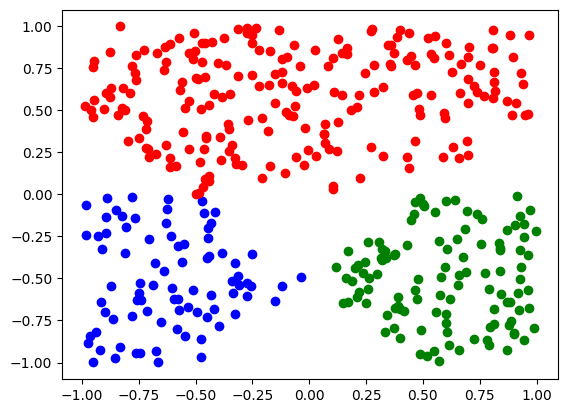

In [13]:
predicted_classes = np.argmax(predictions, axis=1)
for i in range(len(X)):
    if predicted_classes[i] == 0:
        plt.scatter(X[i, 0], X[i, 1], color='blue')
    elif predicted_classes[i] == 1:
        plt.scatter(X[i, 0], X[i, 1], color='red')
    else:
        plt.scatter(X[i, 0], X[i, 1], color='green')

plt.show()


# Multi-Cross

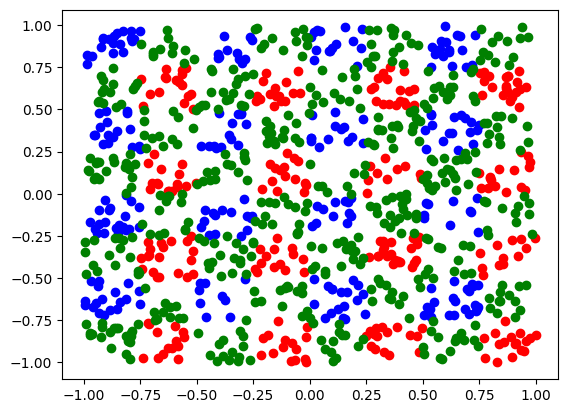

<Figure size 640x480 with 0 Axes>

In [52]:
X = (np.random.random((1000, 2)) * 2.0 - 1.0).astype(np.float64)
Y = np.array([[1, 0, 0] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else 
              [0, 1, 0] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else 
              [0, 0, 1] for p in X], dtype=np.float64)

# Plot the original data
plt.scatter(np.array(list(map(lambda elt: elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:, 0], 
            np.array(list(map(lambda elt: elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:, 1], 
            color='blue')
plt.scatter(np.array(list(map(lambda elt: elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:, 0], 
            np.array(list(map(lambda elt: elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:, 1], 
            color='red')
plt.scatter(np.array(list(map(lambda elt: elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:, 0], 
            np.array(list(map(lambda elt: elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:, 1], 
            color='green')
plt.show()
plt.clf()

## Linear Model

In [14]:
n_features = 2
n_classes = 3
seed = 0

model = my_lib.create_MyLinearModel(n_features, n_classes, seed)

learning_rate = 0.1
epochs = 1000
is_classification = 1

my_lib.train_MyLinearModel(
    model,
    X,
    Y,
    X,
    Y,
    X.shape[0],
    X.shape[0],
    n_features,
    n_classes,
    learning_rate,
    epochs,
    is_classification
)

Training starting...
Epoch 0: Train Loss: 0.6769, Test Loss: 0.6568, Train Acc: 45.8%, Test Acc: 50.9%
Epoch 1: Train Loss: 0.6591, Test Loss: 0.6568, Train Acc: 46.0%, Test Acc: 50.9%
Epoch 2: Train Loss: 0.6591, Test Loss: 0.6568, Train Acc: 46.0%, Test Acc: 50.9%
Epoch 3: Train Loss: 0.6591, Test Loss: 0.6568, Train Acc: 46.0%, Test Acc: 50.9%
Epoch 4: Train Loss: 0.6591, Test Loss: 0.6568, Train Acc: 46.0%, Test Acc: 50.9%
Epoch 5: Train Loss: 0.6591, Test Loss: 0.6568, Train Acc: 46.0%, Test Acc: 50.9%
Epoch 6: Train Loss: 0.6591, Test Loss: 0.6568, Train Acc: 46.0%, Test Acc: 50.9%
Epoch 7: Train Loss: 0.6591, Test Loss: 0.6568, Train Acc: 46.0%, Test Acc: 50.9%
Epoch 8: Train Loss: 0.6591, Test Loss: 0.6568, Train Acc: 46.0%, Test Acc: 50.9%
Epoch 9: Train Loss: 0.6591, Test Loss: 0.6568, Train Acc: 46.0%, Test Acc: 50.9%
Epoch 10: Train Loss: 0.6591, Test Loss: 0.6568, Train Acc: 46.0%, Test Acc: 50.9%
Epoch 11: Train Loss: 0.6591, Test Loss: 0.6568, Train Acc: 46.0%, Test Acc:

0

In [15]:
predictions_ptr = my_lib.predict_MyLinearModel(model, X, X.shape[0], n_features, is_classification)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(X.shape[0], n_classes))

predictions

array([[0.02872996, 0.28957076, 0.67247249],
       [0.12621028, 0.2398612 , 0.6262055 ],
       [0.14297927, 0.23463883, 0.62385637],
       ...,
       [0.16596001, 0.22045261, 0.60839759],
       [0.05209151, 0.27762549, 0.66151399],
       [0.16833887, 0.20947519, 0.58967445]])

## RBF

In [55]:
n_centers = len(X)
input_dim = 2
output_dim = 3
gamma = 0.01
seed = 0

centers = X
model = my_lib.create_MyRBF(centers, n_centers, input_dim, output_dim, gamma, seed)

learning_rate = 0.1
epochs = 1000
is_classification = True

my_lib.train_MyRBF(
    model,
    X,
    Y,
    X,
    Y,
    X.shape[0],
    X.shape[0],
    input_dim,
    output_dim,
    learning_rate,
    epochs,
    is_classification
)

LOOOL
Training starting...
Epoch 0: Train Loss: 3.2640, Test Loss: 2.7840, Train Acc: 27.0%, Test Acc: 27.6%
Epoch 1: Train Loss: 2.9400, Test Loss: 2.5760, Train Acc: 32.3%, Test Acc: 29.2%
Epoch 2: Train Loss: 2.7640, Test Loss: 2.2240, Train Acc: 36.1%, Test Acc: 31.5%
Epoch 3: Train Loss: 2.4680, Test Loss: 2.1880, Train Acc: 40.7%, Test Acc: 34.4%
Epoch 4: Train Loss: 2.3360, Test Loss: 2.4320, Train Acc: 43.9%, Test Acc: 30.3%
Epoch 5: Train Loss: 2.2360, Test Loss: 2.0840, Train Acc: 45.6%, Test Acc: 25.2%
Epoch 6: Train Loss: 2.2200, Test Loss: 2.3240, Train Acc: 46.1%, Test Acc: 26.9%
Epoch 7: Train Loss: 2.1480, Test Loss: 2.3280, Train Acc: 47.1%, Test Acc: 25.3%
Epoch 8: Train Loss: 2.1240, Test Loss: 2.2240, Train Acc: 48.6%, Test Acc: 25.9%
Epoch 9: Train Loss: 2.1040, Test Loss: 2.1760, Train Acc: 48.4%, Test Acc: 25.0%
Epoch 10: Train Loss: 2.0680, Test Loss: 2.6960, Train Acc: 48.2%, Test Acc: 24.9%
Epoch 11: Train Loss: 2.0600, Test Loss: 2.1520, Train Acc: 49.1%, Tes

0

In [56]:
predictions_ptr = my_lib.predict_MyRBF(model, X, X.shape[0], input_dim, is_classification)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(X.shape[0], output_dim))
predictions

array([[ 1., -1., -1.],
       [-1.,  1.,  1.],
       [ 1.,  1., -1.],
       ...,
       [-1.,  1., -1.],
       [ 1., -1.,  1.],
       [ 1., -1.,  1.]])

## MLP

In [23]:
layer_sizes = np.array([2, 5, 4, 3], dtype=np.int32)  # Example layer sizes: input layer with 2 neurons, one hidden layer with 4 neurons, and output layer with 3 neurons
mlp = my_lib.create_MyMLP(layer_sizes, len(layer_sizes), 42)  # Seed for reproducibility

# Train the MLP model
my_lib.train_MyMLP(
    mlp,
    X.flatten(),
    Y.flatten(),
    X.flatten(),
    Y.flatten(),
    len(X),
    len(X),
    X.shape[1],
    Y.shape[1],
    0.1, 
    10000,
    True 
)

# Get predictions
predictions_ptr = my_lib.predict_MyMLP(mlp, X.flatten(), len(X), X.shape[1], True)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(len(X), 3))

Training starting...
Epoch 0: Train Loss: 0.6696, Test Loss: 0.6296, Train Acc: 45.5%, Test Acc: 50.7%
Epoch 1: Train Loss: 0.6368, Test Loss: 0.6252, Train Acc: 47.7%, Test Acc: 48.5%
Epoch 2: Train Loss: 0.6354, Test Loss: 0.6242, Train Acc: 47.5%, Test Acc: 49.5%
Epoch 3: Train Loss: 0.6347, Test Loss: 0.6237, Train Acc: 47.5%, Test Acc: 50.3%
Epoch 4: Train Loss: 0.6343, Test Loss: 0.6233, Train Acc: 47.2%, Test Acc: 50.9%
Epoch 5: Train Loss: 0.6340, Test Loss: 0.6230, Train Acc: 47.4%, Test Acc: 50.8%
Epoch 6: Train Loss: 0.6338, Test Loss: 0.6229, Train Acc: 47.2%, Test Acc: 50.5%
Epoch 7: Train Loss: 0.6337, Test Loss: 0.6228, Train Acc: 47.1%, Test Acc: 50.1%
Epoch 8: Train Loss: 0.6336, Test Loss: 0.6227, Train Acc: 47.2%, Test Acc: 49.9%
Epoch 9: Train Loss: 0.6335, Test Loss: 0.6226, Train Acc: 47.0%, Test Acc: 49.7%
Epoch 10: Train Loss: 0.6334, Test Loss: 0.6226, Train Acc: 47.0%, Test Acc: 49.6%
Epoch 11: Train Loss: 0.6334, Test Loss: 0.6225, Train Acc: 47.1%, Test Acc:

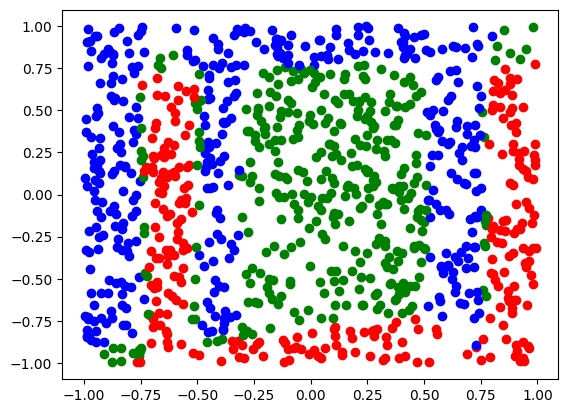

0

In [24]:
# Plotting the data points based on predictions
predicted_classes = np.argmax(predictions, axis=1)
for i in range(len(X)):
    if predicted_classes[i] == 0:
        plt.scatter(X[i, 0], X[i, 1], color='blue')
    elif predicted_classes[i] == 1:
        plt.scatter(X[i, 0], X[i, 1], color='red')
    else:
        plt.scatter(X[i, 0], X[i, 1], color='green')

plt.show()

# Destroy the MLP model
my_lib.destroy_MyMLP(mlp)

# Regression

# Linear Simple 2D

## MLP

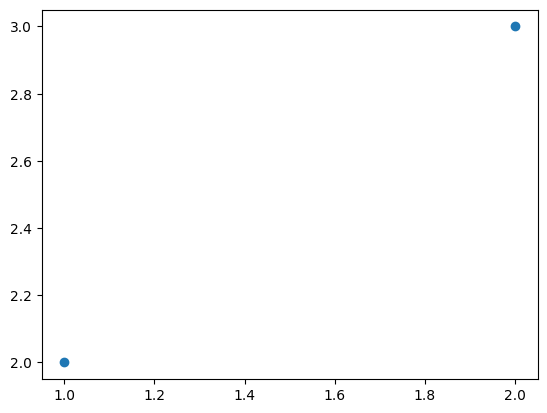

<Figure size 640x480 with 0 Axes>

In [3]:
X = np.array([[1], [2]]).astype(np.float64)
Y = np.array([[2], [3]]).astype(np.float64)
plt.scatter(X,Y)
plt.show()
plt.clf()

In [8]:
layer_sizes = np.array([1, 1], dtype=np.int32)
mlp = my_lib.create_MyMLP(layer_sizes, len(layer_sizes), 42)

# Train the MLP model
my_lib.train_MyMLP(
    mlp,
    X.flatten(),
    Y.flatten(),
    X.flatten(),  # Using the same data for testing for simplicity
    Y.flatten(),
    len(X),
    len(X),
    X.shape[1],
    Y.shape[1],  # Output dimension is 1
    0.01,  # Learning rate
    1000,  # Number of epochs
    False  # Not a classification problem, this is regression
)

# Get predictions
predictions_ptr = my_lib.predict_MyMLP(mlp, X.flatten(), len(X), X.shape[1], False)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(len(X), 1))

Training starting...
Epoch 0: Train Loss: 5.4321, Test Loss: 4.8572, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 1: Train Loss: 4.7235, Test Loss: 4.2240, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 2: Train Loss: 4.1075, Test Loss: 3.6735, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 3: Train Loss: 3.5719, Test Loss: 3.1949, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 4: Train Loss: 3.1064, Test Loss: 2.7789, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 5: Train Loss: 2.7016, Test Loss: 2.4171, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 6: Train Loss: 2.3498, Test Loss: 2.1026, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 7: Train Loss: 2.0438, Test Loss: 1.8292, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 8: Train Loss: 1.7779, Test Loss: 1.5914, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 9: Train Loss: 1.5467, Test Loss: 1.3847, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 10: Train Loss: 1.3457, Test Loss: 1.2050, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 11: Train Loss: 1.1709, Test Loss: 1.0487, Train

In [9]:
print(predictions)

[[1.97577083]
 [3.01423155]]


# Non Linear Simple 2D

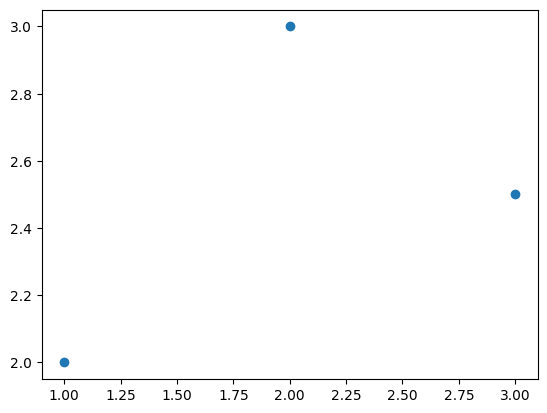

<Figure size 640x480 with 0 Axes>

In [3]:
X = np.array([[1], [2], [3]]).astype(np.float64)
Y = np.array([2, 3, 2.5]).astype(np.float64)

plt.scatter(X,Y)
plt.show()
plt.clf()

In [11]:
layer_sizes = np.array([1, 4, 1], dtype=np.int32)  # Example layer sizes: input layer with 1 neuron, one hidden layer with 4 neurons, and output layer with 1 neuron
mlp = my_lib.create_MyMLP(layer_sizes, len(layer_sizes), 42)  # Seed for reproducibility

# Train the MLP model
my_lib.train_MyMLP(
    mlp,
    X.flatten(),
    Y.flatten(),
    X.flatten(),  # Using the same data for testing for simplicity
    Y.flatten(),
    len(X),
    len(X),
    X.shape[1],
    1,  # Output dimension is 1
    0.1,  # Learning rate
    5000,  # Number of epochs
    False  # Not a classification problem, this is regression
)

# Get predictions


Training starting...
Epoch 0: Train Loss: 3.1257, Test Loss: 0.2428, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 1: Train Loss: 0.2106, Test Loss: 0.0937, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 2: Train Loss: 0.1342, Test Loss: 0.0826, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 3: Train Loss: 0.1278, Test Loss: 0.0809, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 4: Train Loss: 0.1264, Test Loss: 0.0803, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 5: Train Loss: 0.1258, Test Loss: 0.0799, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 6: Train Loss: 0.1253, Test Loss: 0.0796, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 7: Train Loss: 0.1248, Test Loss: 0.0793, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 8: Train Loss: 0.1244, Test Loss: 0.0790, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 9: Train Loss: 0.1241, Test Loss: 0.0788, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 10: Train Loss: 0.1237, Test Loss: 0.0786, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 11: Train Loss: 0.1234, Test Loss: 0.0784, Train

0

In [12]:
predictions_ptr = my_lib.predict_MyMLP(mlp, X.flatten(), len(X), X.shape[1], False)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(len(X), 1))
print(predictions)

[[2. ]
 [3. ]
 [2.5]]


# Linear Simple 3D

/tmp/ipykernel_661890/1263406800.py:6: MatplotlibDeprecationWarning: Axes3D(fig) adding itself to the figure is deprecated since 3.4. Pass the keyword argument auto_add_to_figure=False and use fig.add_axes(ax) to suppress this warning. The default value of auto_add_to_figure will change to False in mpl3.5 and True values will no longer work in 3.6.  This is consistent with other Axes classes.
  ax = Axes3D(fig)


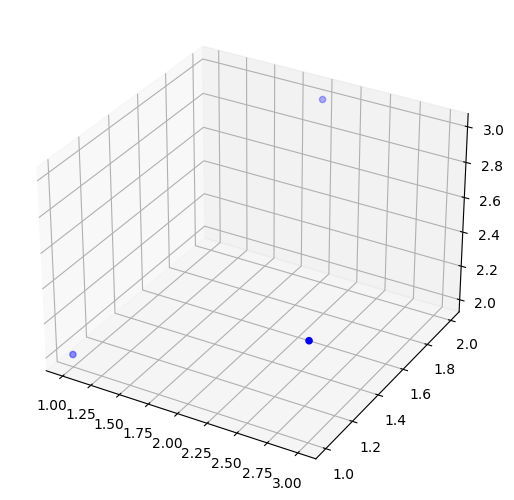

<Figure size 640x480 with 0 Axes>

In [14]:
X = np.array([[1, 1], [2, 2], [3, 1]]).astype(np.float64)
Y = np.array([2, 3, 2.5]).astype(np.float64)

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y, c='blue')
plt.show()
plt.clf()

## MLP

In [15]:
layer_sizes = np.array([2, 4, 1], dtype=np.int32)  
mlp = my_lib.create_MyMLP(layer_sizes, len(layer_sizes), 42)

my_lib.train_MyMLP(
    mlp,
    X.flatten(),
    Y.flatten(),
    X.flatten(),
    Y.flatten(),
    len(X),
    len(X),
    X.shape[1],
    1, 
    0.01,
    1000,
    False
)

Training starting...
Epoch 0: Train Loss: 10.5071, Test Loss: 8.5391, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 1: Train Loss: 7.7687, Test Loss: 6.2486, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 2: Train Loss: 5.6602, Test Loss: 4.4693, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 3: Train Loss: 4.0203, Test Loss: 3.0892, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 4: Train Loss: 2.7560, Test Loss: 2.0578, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 5: Train Loss: 1.8267, Test Loss: 1.3411, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 6: Train Loss: 1.1934, Test Loss: 0.8774, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 7: Train Loss: 0.7882, Test Loss: 0.5889, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 8: Train Loss: 0.5362, Test Loss: 0.4105, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 9: Train Loss: 0.3797, Test Loss: 0.2989, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 10: Train Loss: 0.2812, Test Loss: 0.2279, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 11: Train Loss: 0.2181, Test Loss: 0.1818, Trai

In [16]:
# Get predictions
predictions_ptr = my_lib.predict_MyMLP(mlp, X.flatten(), len(X), X.shape[1], False)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(len(X), 1))

# Print predictions
print("Predictions:", predictions)

Predictions: [[2.00040694]
 [2.99939471]
 [2.5001099 ]]


# Linear Tricky 3D

/tmp/ipykernel_661890/724262376.py:6: MatplotlibDeprecationWarning: Axes3D(fig) adding itself to the figure is deprecated since 3.4. Pass the keyword argument auto_add_to_figure=False and use fig.add_axes(ax) to suppress this warning. The default value of auto_add_to_figure will change to False in mpl3.5 and True values will no longer work in 3.6.  This is consistent with other Axes classes.
  ax = Axes3D(fig)


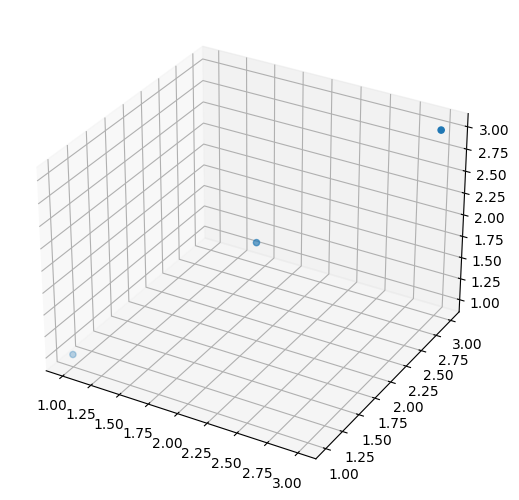

<Figure size 640x480 with 0 Axes>

In [17]:
X = np.array([[1, 1], [2, 2], [3, 3]]).astype(np.float64)
Y = np.array([1, 2, 3]).astype(np.float64)

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

## MLP

In [18]:
layer_sizes = np.array([2, 1], dtype=np.int32)
mlp = my_lib.create_MyMLP(layer_sizes, len(layer_sizes), 42)

my_lib.train_MyMLP(
    mlp,
    X.flatten(),
    Y.flatten(),
    X.flatten(),
    Y.flatten(),
    len(X),
    len(X),
    X.shape[1],
    1,
    0.01,
    1000,
    False
)

Training starting...
Epoch 0: Train Loss: 1.5306, Test Loss: 0.9200, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 1: Train Loss: 0.7896, Test Loss: 0.4738, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 2: Train Loss: 0.4082, Test Loss: 0.2446, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 3: Train Loss: 0.2119, Test Loss: 0.1269, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 4: Train Loss: 0.1109, Test Loss: 0.0666, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 5: Train Loss: 0.0590, Test Loss: 0.0358, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 6: Train Loss: 0.0323, Test Loss: 0.0200, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 7: Train Loss: 0.0186, Test Loss: 0.0121, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 8: Train Loss: 0.0116, Test Loss: 0.0080, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 9: Train Loss: 0.0081, Test Loss: 0.0060, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 10: Train Loss: 0.0062, Test Loss: 0.0050, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 11: Train Loss: 0.0053, Test Loss: 0.0045, Train

0

In [20]:
predictions_ptr = my_lib.predict_MyMLP(mlp, X.flatten(), len(X), X.shape[1], False)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(len(X), 1))

print("Predictions:\n", predictions)

Predictions:
 [[1.00179818]
 [2.00050688]
 [2.99921558]]


# Non Linear Simple 3D :

/tmp/ipykernel_661890/1959386919.py:6: MatplotlibDeprecationWarning: Axes3D(fig) adding itself to the figure is deprecated since 3.4. Pass the keyword argument auto_add_to_figure=False and use fig.add_axes(ax) to suppress this warning. The default value of auto_add_to_figure will change to False in mpl3.5 and True values will no longer work in 3.6.  This is consistent with other Axes classes.
  ax = Axes3D(fig)


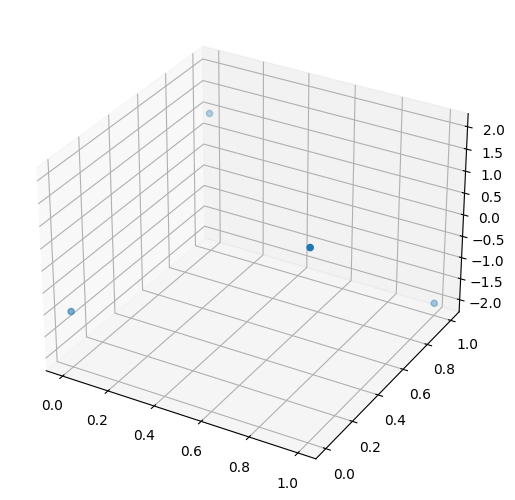

<Figure size 640x480 with 0 Axes>

In [22]:
X = np.array([[1, 0], [0, 1], [1, 1], [0, 0]]).astype(np.float64)
Y = np.array([2, 1, -2, -1]).astype(np.float64)

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

## MLP

In [26]:
layer_sizes = np.array([2, 2, 1], dtype=np.int32)
mlp = my_lib.create_MyMLP(layer_sizes, len(layer_sizes), 42)

my_lib.train_MyMLP(
    mlp,
    X.flatten(),
    Y.flatten(),
    X.flatten(),
    Y.flatten(),
    len(X),
    len(X),
    X.shape[1],
    1,
    0.1,
    1000,
    False
)

Training starting...
Epoch 0: Train Loss: 2.9385, Test Loss: 2.2496, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 1: Train Loss: 2.8629, Test Loss: 2.2616, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 2: Train Loss: 2.8386, Test Loss: 2.2407, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 3: Train Loss: 2.7836, Test Loss: 2.2045, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 4: Train Loss: 2.7215, Test Loss: 2.1639, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 5: Train Loss: 2.6606, Test Loss: 2.1217, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 6: Train Loss: 2.6016, Test Loss: 2.0781, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 7: Train Loss: 2.5435, Test Loss: 2.0329, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 8: Train Loss: 2.4853, Test Loss: 1.9862, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 9: Train Loss: 2.4263, Test Loss: 1.9383, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 10: Train Loss: 2.3665, Test Loss: 1.8896, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 11: Train Loss: 2.3062, Test Loss: 1.8408, Train

0

In [27]:
predictions_ptr = my_lib.predict_MyMLP(mlp, X.flatten(), len(X), X.shape[1], False)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(len(X), 1))

print("Predictions:\n", predictions)

Predictions:
 [[ 2.]
 [ 1.]
 [-2.]
 [-1.]]
